<a href="https://colab.research.google.com/github/luisy-eng/ECE491E_Lab1/blob/main/Task2/Task2_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Customize Dataset — CIFAR-10

The purpose of Task 2 is to replace the FashionMNIST dataset used in the
PyTorch tutorial with the CIFAR-10 dataset.

For this task, the CIFAR-10 dataset will be:

1. Loaded using `torchvision.datasets`.
2. Converted into PyTorch tensors.
3. Normalized before being provided to the neural network.
4. Divided into 80% training data and 20% testing data.
5. Loaded into PyTorch `DataLoader` objects for use in later tasks.

The resulting dataset will be used as the input for the modified neural
network developed in Task 3.

## 1. Import Required Libraries

PyTorch and TorchVision provide the main tools needed to prepare the dataset.

- `torch` provides the core tensor and machine learning functionality.
- `torchvision.datasets` provides access to the CIFAR-10 dataset.
- `ToTensor` converts images into PyTorch tensors.
- `Normalize` is used to normalize the image data.
- `Compose` combines multiple transformations into a single preprocessing pipeline.
- `random_split` is used to create the required 80/20 training and testing split.
- `DataLoader` organizes the dataset into batches that can later be passed to the neural network.
- `matplotlib` is used to visualize samples from the dataset.

In [1]:
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Compose


## 2. Define the CIFAR-10 Preprocessing Transform

Before the CIFAR-10 images are used by the neural network, they must be
converted into PyTorch tensors and normalized.

CIFAR-10 images are RGB images, meaning that each image contains three
channels: red, green, and blue. Each image has dimensions of 32 × 32 pixels.

`ToTensor()` converts an image into a tensor with the shape:

`[Channels, Height, Width] = [3, 32, 32]`

It also converts the original pixel values into floating-point values between
0 and 1.

The `Normalize()` transform is then applied independently to each of the three
RGB channels. A mean of 0.5 and standard deviation of 0.5 are used for each
channel.

Normalization is calculated as:

\[
x' = \frac{x-\mu}{\sigma}
\]

where \(x\) is the input value, \(\mu\) is the mean, and \(\sigma\) is the
standard deviation. With a mean and standard deviation of 0.5, the image
values are approximately transformed from the range [0, 1] to [-1, 1].

In [2]:
transform = Compose([
    ToTensor(),
    Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

## 3. Load the CIFAR-10 Dataset

CIFAR-10 contains 60,000 color images divided among 10 classes. The dataset
normally contains 50,000 predefined training images and 10,000 predefined
testing images.

For this project, however, the instructions require an 80% training and 20%
testing split. Therefore, the original CIFAR-10 training and testing portions
are first loaded and combined into a single dataset containing all 60,000
images.

A new 80/20 split will then be created from the complete dataset.

In [3]:
cifar_train = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

cifar_test = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

full_dataset = ConcatDataset([
    cifar_train,
    cifar_test
])

print(f"Total number of CIFAR-10 samples: {len(full_dataset)}")

100%|██████████| 170M/170M [06:42<00:00, 423kB/s]


Total number of CIFAR-10 samples: 60000


## 4. Create the 80/20 Training and Testing Split

The complete CIFAR-10 dataset contains 60,000 images. According to the project
requirements, 80% of the samples are used for training and the remaining 20%
are used for testing.

Therefore:

- Training set: 48,000 images
- Testing set: 12,000 images

PyTorch's `random_split()` function is used to randomly assign the samples to
the two datasets.

A manual random seed of 42 is also specified. This makes the split
reproducible, meaning that running the notebook again will assign the same
samples to the training and testing sets.


In [4]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_data, test_data = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples:  {len(test_data)}")

Training samples: 48000
Testing samples:  12000


## 5. Create the DataLoaders

After splitting the dataset, PyTorch `DataLoader` objects are created for the
training and testing sets.

A batch size of 64 is used, matching the batch size used during Task 1.

The training DataLoader uses `shuffle=True` so that the order of the training
samples is randomized during training. This prevents the model from repeatedly
seeing samples in exactly the same order.

The testing DataLoader uses `shuffle=False` because randomizing the order of
the test samples is not necessary when evaluating the model.

In [5]:
batch_size = 64

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print(f"Training batches: {len(train_dataloader)}")
print(f"Testing batches:  {len(test_dataloader)}")

Training batches: 750
Testing batches:  188


## 6. Verify the Dataset Dimensions

Before constructing the neural network, a batch is retrieved from the training
DataLoader to verify the dimensions of the CIFAR-10 data.

Each CIFAR-10 image contains three color channels and has a resolution of
32 × 32 pixels. Therefore, an individual image has the shape:

`[3, 32, 32]`

When the image is flattened for use in the feedforward neural network, the
number of input features becomes:

\[
3 \times 32 \times 32 = 3072
\]

Therefore, the input layer of the feedforward neural network developed in
Task 3 will need to accept 3,072 features.

In [6]:
images, labels = next(iter(train_dataloader))

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Single image shape: {images[0].shape}")

input_features = images[0].numel()

print(f"Number of features after flattening: {input_features}")

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])
Single image shape: torch.Size([3, 32, 32])
Number of features after flattening: 3072


## 7. Visualize CIFAR-10 Samples

Several samples from the training dataset are displayed to verify that the
dataset was loaded and processed correctly.

Because the images were normalized before being placed in the DataLoader, the
normalization is reversed before displaying them with Matplotlib.

The normalized image is converted back using:

\[
x = 0.5x' + 0.5
\]

The tensor dimensions are also rearranged from PyTorch's
`[Channels, Height, Width]` format to Matplotlib's
`[Height, Width, Channels]` format.

Each displayed image is captioned with its corresponding CIFAR-10 class.

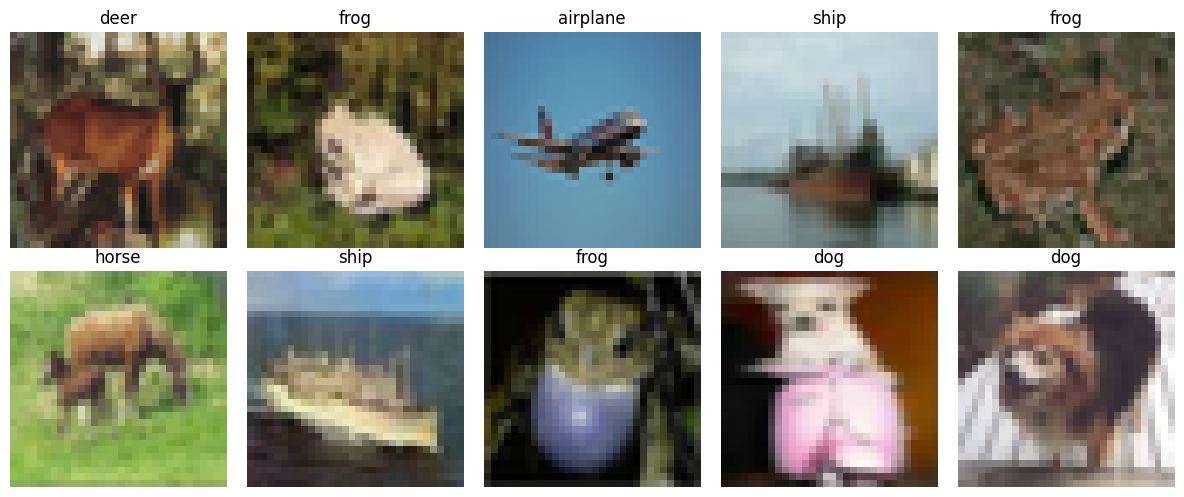

In [7]:
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

images, labels = next(iter(train_dataloader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):

    # Reverse the normalization
    image = images[i] * 0.5 + 0.5

    # Convert [C, H, W] to [H, W, C] for Matplotlib
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(classes[labels[i].item()])
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "Task2_CIFAR10_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Task 2 Summary

Task 2 replaced the FashionMNIST dataset used in the original PyTorch tutorial
with CIFAR-10.

The CIFAR-10 dataset was successfully:

- Loaded using `torchvision.datasets.CIFAR10`.
- Converted into PyTorch tensors.
- Normalized across all three RGB channels.
- Combined into a dataset containing 60,000 images.
- Randomly divided into 48,000 training samples and 12,000 testing samples,
  producing the required 80/20 split.
- Organized into training and testing DataLoaders with a batch size of 64.
- Verified to contain images with dimensions `[3, 32, 32]`.

Each image therefore contains 3,072 features when flattened. This value will
be used as the input size for the modified feedforward neural network in
Task 3.